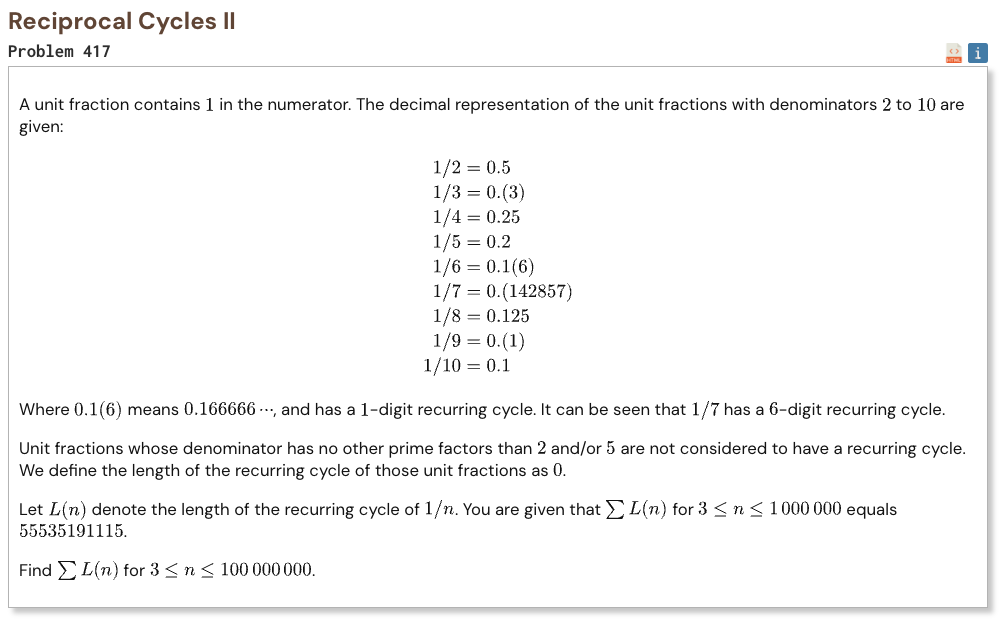

## Initial approach

-   remove all factors of 2 and 5 because they do not change the recurring cycle
-   for the remaining denominator the cycle length is the multiplicative order of 10
-   find the smallest prime factor of every number with a sieve
-   find the order for each prime by starting from one less than the prime and removing unnecessary factors
-   build the order of composite numbers from the orders of their prime power parts
-   use the least common multiple when several different prime factors appear
-   count how many denominators have the same reduced denominator after removing 2s and 5s
-   use array to store the sieve more compactly because the limit is very large

In [1]:
%%time

import numpy as np
from math import comb

MOD = 10**9
BASE = 32768


def mod_matmul(a, b):
    a0 = a % BASE
    a1 = a // BASE
    b0 = b % BASE
    b1 = b // BASE

    c0 = a0 @ b0
    c1 = a0 @ b1 + a1 @ b0
    c2 = a1 @ b1

    return (
        c0 % MOD
        + (c1 % MOD) * BASE
        + (c2 % MOD) * BASE * BASE
    ) % MOD


def build_matrices(k):
    states = []
    index = {}

    for a in range(k + 1):
        for c in range(k - a + 1):
            index[(a, c)] = len(states)
            states.append((a, c))

    size = len(states)

    visited = np.zeros((size, size), dtype=np.int64)
    missed = np.zeros((size, size), dtype=np.int64)

    for i, (a, c) in enumerate(states):
        b = k - a - c

        for a0 in range(a + 1):
            for a1 in range(a - a0 + 1):
                a2 = a - a0 - a1

                ways = comb(a, a0) * comb(a - a0, a1)

                new_a = a0 + b
                new_c = a2

                j = index[(new_a, new_c)]

                if new_a == 0:
                    missed[i, j] = (missed[i, j] + ways) % MOD
                else:
                    visited[i, j] = (visited[i, j] + ways) % MOD

    target = index[(k, 0)]

    return visited, missed, target


def multiply_pairs(x, y):
    a, b = x
    c, d = y

    normal = mod_matmul(a, c)

    one_miss = (
        mod_matmul(b, c)
        + mod_matmul(a, d)
    ) % MOD

    return normal, one_miss


def matrix_power(visited, missed, exponent):
    size = len(visited)

    result = (
        np.eye(size, dtype=np.int64),
        np.zeros((size, size), dtype=np.int64)
    )

    base = (visited, missed)

    while exponent > 0:
        if exponent % 2 == 1:
            result = multiply_pairs(result, base)

        base = multiply_pairs(base, base)
        exponent //= 2

    return result


def frog_trip(m, n):
    crossings = 2 * m

    visited, missed, target = build_matrices(crossings)

    zero_miss, one_miss = matrix_power(
        visited,
        missed,
        n - 1
    )

    return (
        int(zero_miss[target, target])
        + int(one_miss[target, target])
    ) % MOD


result = frog_trip(10, 10**12)

print("Result:", result)

Result: 898082747
CPU times: user 3.76 s, sys: 49.5 ms, total: 3.81 s
Wall time: 3.92 s
